# 手撕PPO算法

In [5]:
import gymnasium as gym
import numpy as np
from collections import deque
import random
import torch
from torch import nn
import torch.nn.functional as F
from torch.distributions import Categorical
from torch.optim.lr_scheduler import StepLR

In [6]:
%%html
<img src="img/PPO.png", width=600,height=300>

## PPO的计算公式
$$
J^{\mathrm{PPO}-\mathrm{Clip}}(\theta)=\mathbb{E}_t\left[\min\left\{\frac{\pi_\theta(a_t|s_t)}{\pi_{\theta_{\mathrm{old}}}(a_t|s_t)}\cdot A_t^{\pi_{\theta_{\mathrm{old}}}},\quad\mathrm{clip}\left(\frac{\pi_\theta(a_t|s_t)}{\pi_{\theta_{\mathrm{old}}}(a_t|s_t)},1-\varepsilon,1+\varepsilon\right)\cdot A_t^{\pi_{\theta_{\mathrm{old}}}}\right\}\right]
$$

# 定义Actor和Critic网络

In [19]:
# Actor网络
class PolicyNetwork(nn.Module):
    def __init__(self, state_size, action_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_size, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, action_size),
        )

    def forward(self, x):
        return self.net(x)


# Critic网络
class ValueNetwork(nn.Module):
    def __init__(self, state_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_size, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.net(x)

# 训练和预测的代码

In [32]:
class PPO():
    def __init__(self, env):

        # 超参数设置
        self.actor_lr = 2e-4                  # actor的学习率
        self.critic_lr = 8e-4                 # critic的学习率
        self.gamma = 0.995                    # 奖励的折扣因子
        self.gae_lambda = 0.97                # GAE的折扣因子
        self.clip_ratio = 0.15                # PPO clip的ratio
        self.update_epochs = 4                # PPO内循环的epoch数
        self.actor_gradnorm = 0.6             # actor的梯度裁剪
        self.critic_gradnorm = 0.8            # critic的梯度裁剪

        # 获取state size和action size
        num_states = env.observation_space.shape[0]
        num_actions = env.action_space.n

        # 初始化网络
        self.actor = PolicyNetwork(num_states, num_actions)
        self.critic = ValueNetwork(num_states)

        # 优化器设置
        self.actor_optim = torch.optim.Adam(self.actor.parameters(), lr=self.actor_lr)
        self.critic_optim = torch.optim.Adam(self.critic.parameters(), lr=self.critic_lr)

        # 学习率的调度
        self.actor_scheduler = StepLR(self.actor_optim, step_size=100, gamma=0.95)
        self.critic_scheduler = StepLR(self.critic_optim, step_size=100, gamma=0.95)


    def get_action(self, state):
        state_tensor = torch.FloatTensor(state).unsqueeze(0)
        with torch.no_grad():
            logits = self.actor(state_tensor)
        probs = torch.softmax(logits, dim=-1)
        action = torch.multinomial(probs, 1).item()
        return action

    def compute_gae(self, rewards, values, next_values, dones):
        advantages = np.zeros_like(rewards)
        last_gae = 0 #GAE是从前往后计算的，最后一个初始值为0
        #len 确定范围，range 生成索引序列，reversed 把顺序倒过来。
        for t in reversed(range(len(rewards))):
            if dones[t]:
                delta = rewards[t] - values[t] # TD error
                last_gae = delta
            else:
                delta = rewards[t] + self.gamma * next_values[t] - values[t] # TD error
                last_gae = delta + self.gamma * self.gae_lambda * last_gae
            advantages[t] = last_gae
            
        return torch.FloatTensor(advantages)
    
    def update(self, states, actions, rewards, next_states, dones):
        # 转换为张量
        states = torch.FloatTensor(np.array(states))
        actions = torch.LongTensor(np.array(actions))
        rewards = torch.FloatTensor(np.array(rewards))
        next_states = torch.FloatTensor(np.array(next_states))
        dones = torch.BoolTensor(np.array(dones))

        # 计算价值估计
        with torch.no_grad():
            current_values = self.critic(states).squeeze()#状态价值 V(s) 是一个标量,[batch_size,1] 到[batch_size]
            next_values = self.critic(next_states).squeeze()
            next_values[dones] = 0.0 #找到true的位置全部变成0

        # 计算GAE
        advantages = self.compute_gae(
            rewards.numpy(),
            current_values.numpy(),
            next_values.numpy(),
            dones.numpy())

        # 标准化优势
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        # 获取旧策略的对数概率
        # 作为后续计算 ratio 的分母
        with torch.no_grad():
            old_logits = self.actor(states)
            old_probs = torch.softmax(old_logits, dim=-1)  # [batch_size, num_actions]
            old_log_probs = torch.log(old_probs.gather(1, actions.unsqueeze(1))).squeeze() # [batch_size]

        # 策略优化 (actor模型)
        for _ in range(self.update_epochs):
            # 获取新策略的对数概率
            logits = self.actor(states)
            probs = torch.softmax(logits, dim=-1)
            new_log_probs = torch.log(probs.gather(1, actions.unsqueeze(1))).squeeze()

            # 计算新老策略的比值
            ratios = torch.exp(new_log_probs - old_log_probs) # new_prob/old_prob
            clipped_ratios = torch.clamp(ratios, 1 - self.clip_ratio, 1 + self.clip_ratio)
            policy_loss = -torch.min(ratios * advantages, clipped_ratios * advantages).mean()

            #进行梯度清零和梯度计算
            self.actor_optim.zero_grad()
            policy_loss.backward()
            # 梯度剪裁
            torch.nn.utils.clip_grad_norm_(self.actor.parameters(), self.actor_gradnorm)
            self.actor_optim.step()

        # 价值优化（critic模型）
        for _ in range(self.update_epochs):
            current_values = self.critic(states).squeeze() # 预测值
            target_values = rewards + self.gamma * next_values # 目标值
            value_loss = F.mse_loss(current_values, target_values)

            self.critic_optim.zero_grad()
            value_loss.backward()
            # 梯度剪裁
            torch.nn.utils.clip_grad_norm_(self.critic.parameters(), self.critic_gradnorm)
            self.critic_optim.step()
        
        # 更新学习率
        self.actor_scheduler.step()
        self.critic_scheduler.step()

        return policy_loss, value_loss

In [33]:
# 训练流程
def train_ppo(env, agent, n_episode):
    rewards_per_episode = []

    for episode in range(n_episode):
        state, _ = env.reset()
        episode_data = {
            "states": [],
            "actions": [],
            "rewards": [],
            "next_states": [],
            "dones": []
        }
        total_reward = 0
        done = False

        while not done:
            action = agent.get_action(state)
            next_state, reward, done, truncated, _ = env.step(action)
            done = done or truncated

            # 存储轨迹
            episode_data["states"].append(state)
            episode_data["actions"].append(action)
            episode_data["rewards"].append(reward)
            episode_data["next_states"].append(next_state)
            episode_data["dones"].append(done)

            state = next_state
            total_reward += reward


        policy_loss, value_loss = agent.update(**episode_data)

        # 记录rewards
        rewards_per_episode.append(total_reward)

        if (episode + 1) % 20 == 0:
            print(f"episode {episode+1}, actor loss: {policy_loss:.4f}, critic loss: {value_loss:.4f}, gain: {np.mean(rewards_per_episode[-100:])}")

    # 保存一下训练好的策略模型
    torch.save(agent.actor.state_dict(), "saved/cartpole_ppo.pt")

    return rewards_per_episode

# 开始训练

In [34]:
n_episode = 300

# 环境初始化
env = gym.make("CartPole-v1")

# 训练启动
ppo = PPO(env)
rewards_per_episode = train_ppo(env, ppo, n_episode)

episode 20, actor loss: 0.0003, critic loss: 4.2243, gain: 25.3
episode 40, actor loss: -0.0015, critic loss: 7.4741, gain: 26.3
episode 60, actor loss: -0.0047, critic loss: 7.3250, gain: 28.883333333333333
episode 80, actor loss: -0.0061, critic loss: 7.3334, gain: 46.575
episode 100, actor loss: -0.0134, critic loss: 19.9001, gain: 67.0
episode 120, actor loss: -0.0105, critic loss: 14.7516, gain: 101.62
episode 140, actor loss: -0.0009, critic loss: 22.2693, gain: 146.17
episode 160, actor loss: -0.0013, critic loss: 8.2600, gain: 206.57
episode 180, actor loss: -0.0045, critic loss: 19.6459, gain: 260.63
episode 200, actor loss: -0.0007, critic loss: 10.3145, gain: 319.5
episode 220, actor loss: -0.0018, critic loss: 18.6331, gain: 372.79
episode 240, actor loss: -0.0022, critic loss: 21.0953, gain: 416.4
episode 260, actor loss: -0.0021, critic loss: 23.8971, gain: 449.19
episode 280, actor loss: -0.0021, critic loss: 27.4921, gain: 475.16
episode 300, actor loss: -0.0021, critic

# 可视化reward曲线

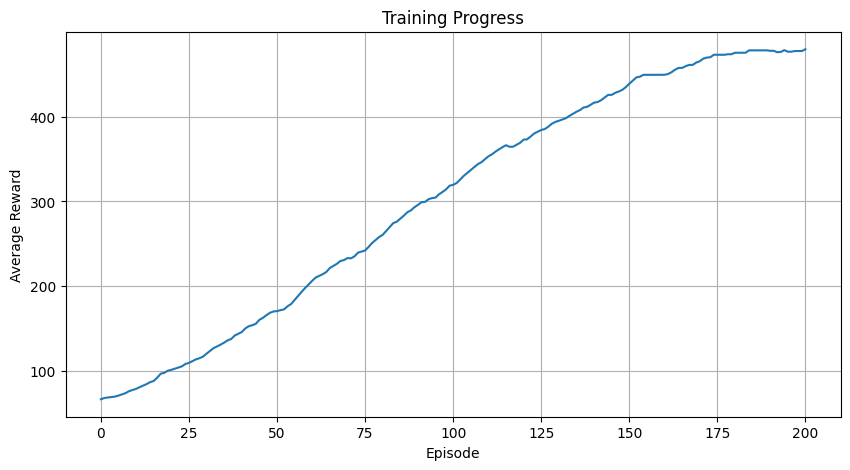

In [35]:
from utils import plot_rewards_curve
plot_rewards_curve(rewards_per_episode)

In [38]:
def test(episodes):
    # 创建环境
    env = gym.make("CartPole-v1", render_mode="human")
    
    num_states = env.observation_space.shape[0]
    num_actions = env.action_space.n

    # 加载训练好的模型
    policy = PolicyNetwork(state_size=num_states, action_size=num_actions)
    policy.load_state_dict(torch.load("saved/cartpole_ppo.pt"))
    policy.eval()       # 预测模式

    for i in range(episodes):
        state, _ = env.reset()
        done = False
        while not done:
            with torch.no_grad():
                state = torch.FloatTensor(state).unsqueeze(0) # [1, 4]
                action = policy(state).argmax().item()
                
            # 执行动作
            state, reward, done, truncated, _ = env.step(action)
            done = done or truncated 

    env.close()

In [39]:
test(1)